In [1]:
# import packages
import pandas as pd
from sts.data import YHData
from sts.data.database import SymbolTable
import datetime
import numpy as np

In [2]:
hy_df = pd.read_csv("/home/yuqing42/projects/systrading/localdata/BAMLH0A0HYM2.csv")

In [3]:
symbol_table = SymbolTable()
symbol_table = symbol_table.add_symbol(YahooSym="SPY", Symbol="SPY")
symbol_table = symbol_table.add_symbol(YahooSym="^VIX", Symbol="VIX")
symbol_table

,YahooSym,AssetClass,Symbol,Description,SymId
0,SPY,None,SPY,None,0
0,^VIX,None,VIX,None,1


In [4]:
sd = datetime.date(2023, 1, 1)
ed = datetime.date.today()

In [7]:
# load data
yh_data = YHData(symbol_table=symbol_table)

df = yh_data.get_hist_data_info(["SPY"], sd, ed, columns=["Close", "Volume"])

KeyError: "None of [Index([('Close', 'Volume')], dtype='object')] are in the [columns]"

In [9]:
ticker = yh_data["SPY"]

In [11]:
df = ticker.history(interval="1d", start=sd, end=ed)

In [13]:
df[["Close", "Volume"]]

,Close,Volume
Date,,
2023-01-03 00:00:00-05:00,377.968140,74850700
2023-01-04 00:00:00-05:00,380.886139,85934100
2023-01-05 00:00:00-05:00,376.538910,76970500
2023-01-06 00:00:00-05:00,385.173737,104189600
2023-01-09 00:00:00-05:00,384.955383,73978100
...,...,...
2023-08-30 00:00:00-04:00,451.010010,69053900
2023-08-31 00:00:00-04:00,450.350006,66084600
2023-09-01 00:00:00-04:00,451.190002,58875700


In [90]:
df2 = df.tail(50).apply(lambda x: x / x[0] - 1.0) * 100
df2.round(2)

,SPY,VIX,spread
Date,,,
2023-06-13,0.00,0.00,0.00
2023-06-14,0.12,-5.00,0.00
2023-06-15,1.36,-0.75,0.72
2023-06-16,1.02,-7.32,-0.72
2023-06-20,0.49,-5.00,0.96
2023-06-21,-0.02,-9.65,3.35
2023-06-22,0.34,-11.64,2.87
2023-06-23,-0.42,-8.01,5.26
2023-06-26,-0.83,-2.46,6.46


In [91]:
import statsmodels.formula.api as fsm

In [92]:
ols = fsm.ols("SPY ~ VIX + spread + 1", df2)

In [93]:
res = ols.fit()

In [94]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    SPY   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     76.93
Date:                Fri, 25 Aug 2023   Prob (F-statistic):           1.50e-15
Time:                        00:06:32   Log-Likelihood:                -60.165
No. Observations:                  50   AIC:                             126.3
Df Residuals:                      47   BIC:                             132.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7285      0.170      4.289      0.000       0.387       1.070
VIX           -0.0769      0.013     -5.727      0.000      -0.104      -0.050
spread        -0.3631      0.030    -12.062      0.000      -0.424      -0.303
==============================================================================
Omnibus:                        1.625   Durbin-Watson:                   0.664
Prob(Omnibus):                  0.444   Jarque-Bera (JB):                1.588
Skew:                           0.397   Prob(JB):                        0.452
Kurtosis:                       2.636   Cond. No.                         13.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [96]:
df2["pred"] = res.predict()

In [99]:
df2.round(2).tail(20)

,SPY,VIX,spread,pred
Date,,,,
2023-07-27,4.01,-1.37,-9.57,4.31
2023-07-28,5.03,-8.76,-8.61,4.53
2023-07-31,5.23,-6.71,-9.33,4.63
2023-08-01,4.93,-4.65,-8.61,4.21
2023-08-02,3.47,10.13,-5.26,1.86
2023-08-03,3.17,8.97,-4.78,1.78
2023-08-04,2.70,17.04,-4.07,0.89
2023-08-07,3.60,7.94,-5.02,1.94
2023-08-08,3.15,9.45,-4.31,1.57


<Axes: xlabel='Date'>

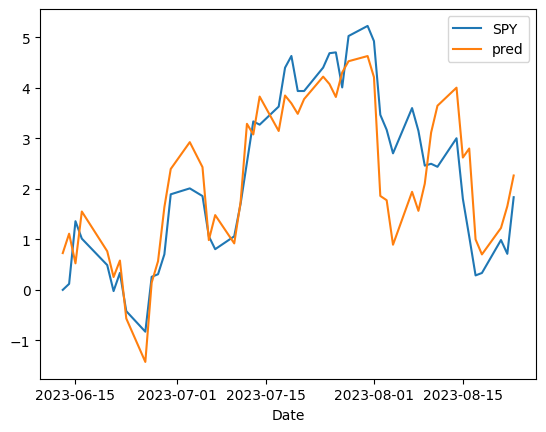

In [100]:
df2.plot(y=["SPY", "pred"])